In [1]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron, SGDClassifier, RidgeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score, train_test_split, HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from datetime import datetime
import joblib

### Preprocessing

In [ ]:
1/0

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some featurs and transform others.

In [3]:
df.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)
df['day'] = df['time'].dt.day
df['weekday'] = df['time'].dt.weekday
df['hour'] = df['time'].dt.hour
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1]).astype(int)
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 
df.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city',  'merchant'], inplace=True)#'job',

### Feature generation

In [4]:
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

str_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        #('encoder', OneHotEncoder(drop='first', sparse_output=False, dtype=bool), str_cols),
        ('transformer', PolynomialFeatures(degree=4, include_bias=False), num_cols),
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

df = preprocessor.fit_transform(df)
df.head()

,amount,city_pop,day,weekday,hour,industry_code,age,amount^2,amount city_pop,amount day,amount weekday,amount hour,amount industry_code,amount age,city_pop^2,city_pop day,city_pop weekday,city_pop hour,city_pop industry_code,city_pop age,day^2,day weekday,day hour,day industry_code,day age,weekday^2,weekday hour,weekday industry_code,weekday age,hour^2,hour industry_code,hour age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 day,amount^2 weekday,amount^2 hour,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop day,amount city_pop weekday,amount city_pop hour,amount city_pop industry_code,amount city_pop age,amount day^2,amount day weekday,amount day hour,amount day industry_code,amount day age,amount weekday^2,amount weekday hour,amount weekday industry_code,amount weekday age,amount hour^2,amount hour industry_code,amount hour age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 day,city_pop^2 weekday,city_pop^2 hour,city_pop^2 industry_code,city_pop^2 age,city_pop day^2,city_pop day weekday,city_pop day hour,city_pop day industry_code,city_pop day age,city_pop weekday^2,city_pop weekday hour,city_pop weekday industry_code,city_pop weekday age,city_pop hour^2,city_pop hour industry_code,city_pop hour age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,day^3,day^2 weekday,day^2 hour,day^2 industry_code,day^2 age,day weekday^2,day weekday hour,day weekday industry_code,day weekday age,day hour^2,day hour industry_code,day hour age,day industry_code^2,day industry_code age,day age^2,weekday^3,weekday^2 hour,weekday^2 industry_code,weekday^2 age,weekday hour^2,weekday hour industry_code,weekday hour age,weekday industry_code^2,weekday industry_code age,weekday age^2,hour^3,hour^2 industry_code,hour^2 age,hour industry_code^2,hour industry_code age,hour age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3,amount^4,amount^3 city_pop,amount^3 day,amount^3 weekday,amount^3 hour,amount^3 industry_code,amount^3 age,amount^2 city_pop^2,amount^2 city_pop day,amount^2 city_pop weekday,amount^2 city_pop hour,amount^2 city_pop industry_code,amount^2 city_pop age,amount^2 day^2,amount^2 day weekday,amount^2 day hour,amount^2 day industry_code,amount^2 day age,amount^2 weekday^2,amount^2 weekday hour,amount^2 weekday industry_code,amount^2 weekday age,amount^2 hour^2,amount^2 hour industry_code,amount^2 hour age,amount^2 industry_code^2,amount^2 industry_code age,amount^2 age^2,amount city_pop^3,amount city_pop^2 day,amount city_pop^2 weekday,amount city_pop^2 hour,amount city_pop^2 industry_code,amount city_pop^2 age,amount city_pop day^2,amount city_pop day weekday,amount city_pop day hour,amount city_pop day industry_code,amount city_pop day age,amount city_pop weekday^2,amount city_pop weekday hour,amount city_pop weekday industry_code,amount city_pop weekday age,amount city_pop hour^2,amount city_pop hour industry_code,amount city_pop hour age,amount city_pop industry_code^2,amount city_pop industry_code age,amount city_pop age^2,amount day^3,amount day^2 weekday,amount day^2 hour,amount day^2 industry_code,amount day^2 age,amount day weekday^2,amount day weekday hour,amount day weekday industry_code,amount day weekday age,amount day hour^2,amount day hour industry_code,amount day hour age,amount day industry_code^2,amount day industry_code age,amount day age^2,amount weekday^3,amount weekday^2 hour,amount weekday^2 industry_code,amount weekday^2 age,amount weekday hour^2,amount weekday hour industry_code,amount weekday hour age,amount weekday industry_code^2,amount weekday industry_code age,amount weekday age^2,amount hour^3,amount hour^2 industry_code,amount hour^2 age,amount hour industry_code^2,amount hour industry_code age,amount hour age^2,amount industry_code^3,amount industry_code^2 age,amount industry_code age^2,amount age^3,city_pop^4,city_pop^3 day,city_pop^3 weekday,city_pop^3 hour,city_pop^3 industry_code,city_

In [6]:
def evaluate(title):
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)#took more than 19h, interrupted    
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)
    
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1)
    
    train_scores = pd.DataFrame()
    test_scores = pd.DataFrame()
    test_scores['metric'] = ['f1', 'recall', 'accuracy', 'precision']
    test_scores.set_index('metric', inplace=True)
    
    for name, model in models.items():
        print(name, datetime.now())
        gs = GridSearchCV(model, cv=cv, n_jobs=10, param_grid={}, scoring='f1_weighted')#must be f1
        gs.fit(X_train, y_train)
        pred = gs.predict(X_test)
        test_scores[name] = [f1_score(y_test, pred, average='weighted'),#remove weighted
                            recall_score(y_test, pred),
                            accuracy_score(y_test, pred),
                            precision_score(y_test, pred)]

        scores = []
        for i in range(cv.get_n_splits()):
            scores.append(gs.cv_results_['split' + str(i) + '_test_score'][0])

        train_scores[name] = scores
    
    print(datetime.now())

    plt.figure(figsize=(7, 6))
    sns.boxplot(data=train_scores).set_title(title)
    
    for i in range(train_scores.shape[1]):    
        y_delta = (train_scores.iloc[:, i].max() - train_scores.iloc[:, i].min()) *  0.01
        plt.text(i - 0.4, train_scores.iloc[:, i].max() + y_delta, 'Test: ' + str(test_scores.iloc[0, i])[:6], fontsize=8)
        #plt.text(i - 0.4, res.iloc[:, i].min() - y_delta*30, 'Train mean: \n' + str(res.iloc[:, i].mean())[:6], fontsize=8)
    
    plt.xticks(rotation=25) 
    
    try:
        saves = joblib.load('preprocessing_saves.jblb')
    except:
        saves = {}
    
    saves[title] = {'train_scores': train_scores, 'test_scores': test_scores}
    joblib.dump(saves, 'preprocessing_saves.jblb') 

### Feature selection

In [7]:
scaler = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), df.select_dtypes(include='number').columns)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        
df = scaler.fit_transform(df)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1)
del df

In [10]:
'''
selector = ColumnTransformer(
    transformers=[('pca', PCA(n_components=0.99, copy=False, random_state=1), X_train.select_dtypes(include='number').columns)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
'''
selector = PCA(n_components=0.99, copy=False, random_state=1)

print('Features before reduction:', X_train.shape[1])
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)
print('Features after reduction:', X_train.shape[1])
X_train_bkp = X_train.copy()
y_train_bkp = y_train.copy()

Features before reduction: 183
Features after reduction: 71


In [9]:

import prince 
print('Features before reduction:', X_train.shape[1])
famd = prince.FAMD(n_components=104, random_state=1, copy=False)
X_train = famd.fit_transform(X_train)
X_test = famd.transform(X_test)
print('Features after reduction:', X_train.shape[1])


Features before reduction: 332


C:\Users\irama\.conda\envs\Python_10\lib\site-packages\prince\pca.py:178: PerformanceWarning: Concatenating sparse arrays with multiple fill values: '[-0.3301893915510423, -0.3252214833775651, -0.3903437095817037, -0.2290860013353927, -0.3780774561147947, -0.3152685290074919, -0.37745888984170656, -0.3616339886162789, -0.26997203071474357, -0.3032869599135339, -0.3240526948470587, -0.3361177449298524, -0.36756712744593956, -0.21635023294672703, -0.9063194710243966, -0.8237627185312878, -0.049630876249387244, -0.2179200935250136, -0.18939841107487598, -0.11224250467516352, -0.2554528384286793, -0.1273091202024115, -0.0941089827183025, -0.06440133734425892, -0.0030421113749895673, -0.2221401024427244, -0.1737957278925361, -0.05423439893220081, -0.17666523244874327, -0.08033324729841147, -0.2235762151746724, -0.1789552883223586, -0.16325210397555537, -0.18186212342108826, -0.1560645633422943, -0.12003818392069379, -0.17435836863944162, -0.13907473883235416, -0.23084995572089012, -0.192167

Features after reduction: 104


In [ ]:


import umap
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=17, random_state=1)
X_train = umap_model.fit_transform(X_train)
X_test = umap_model.transform(X_test)


standartization?


PCA +cat
FAMD
FAMD one-hot
FAMD -all features
UMAP
UMAP one-hot
UMAP  -all features

PF degree




F1 score
Precision
Recall
AUC score (AUC ROC)
Average precision score (AP)
G-Mean


correct traintest after tests


### Handling imbalanced data

In [13]:
#NearMiss
from imblearn.under_sampling import NearMiss
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = NearMiss(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(11450, 104) 5725 5725


In [10]:
#TomekLinks-----------------------------------------------------------------------------------------------------------------------------
from imblearn.under_sampling import TomekLinks
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = TomekLinks(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(971692, 104) 965967 5725


In [ ]:
#ClusterCentroids
from imblearn.under_sampling import ClusterCentroids
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = ClusterCentroids().fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725


C:\Users\irama\.conda\envs\Python_10\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [11]:
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(971692, 104) 965967 5725


In [10]:
#EditedNearestNeighbours
from imblearn.under_sampling import EditedNearestNeighbours
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = EditedNearestNeighbours(n_jobs=5).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(967262, 104) 961537 5725


In [10]:
#Oversampler
from imblearn.over_sampling import RandomOverSampler
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = RandomOverSampler(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(1933562, 104) 966781 966781


In [10]:
#SMOTE
from imblearn.over_sampling import SMOTE
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTE(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(1933562, 104) 966781 966781


In [10]:
#BSMOTE
from imblearn.over_sampling import BorderlineSMOTE
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = BorderlineSMOTE(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))

(972506, 104) 966781 5725
(1933562, 104) 966781 966781


(972506, 104) 966781 5725
(1933330, 104) 966781 966549
Logistic Regression 2024-11-13 19:31:51.631681
SGD 2024-11-13 20:05:56.471482
Nearest Neighbor 2024-11-13 20:06:40.583272
Naive Bayes 2024-11-13 22:25:18.544487
Decision Tree 2024-11-13 22:25:56.915024
Random Forest 2024-11-13 22:43:49.315552
MLPC 2024-11-14 00:32:35.803888
2024-11-14 01:26:52.947620


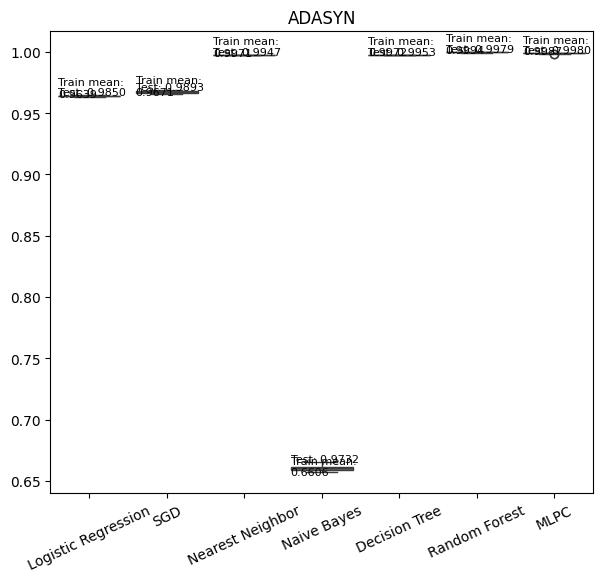

In [14]:
#ADASYN
X_train = X_train_bkp.copy()
y_train = y_train_bkp.copy()
from imblearn.over_sampling import ADASYN
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = ADASYN(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
evaluate('ADASYN')

(972506, 104) 966781 5725
(1920502, 104) 953731 966771
Logistic Regression 2024-11-14 11:40:48.879847
SGD 2024-11-14 12:15:37.628810
Nearest Neighbor 2024-11-14 12:16:19.684808
Naive Bayes 2024-11-14 14:34:18.097709
Decision Tree 2024-11-14 14:34:52.764597
Random Forest 2024-11-14 14:58:05.003364
MLPC 2024-11-14 17:04:34.246697
2024-11-14 17:49:20.875429


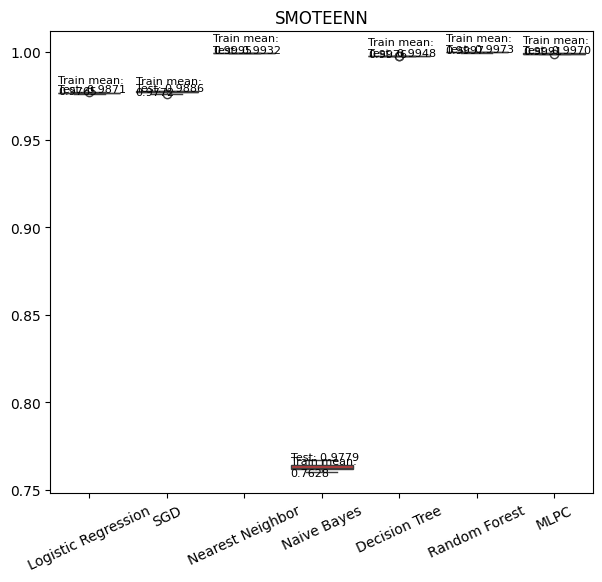

In [19]:
#SMOTEENN
X_train = X_train_bkp.copy()
y_train = y_train_bkp.copy()
from imblearn.combine import SMOTEENN
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTEENN(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
evaluate('SMOTEENN')

(972506, 104) 966781 5725
(1933562, 104) 966781 966781
Logistic Regression 2024-11-14 18:33:13.406531
SGD 2024-11-14 19:10:42.121436
Nearest Neighbor 2024-11-14 19:11:25.803717
Naive Bayes 2024-11-14 21:31:04.371624
Decision Tree 2024-11-14 21:31:43.033924
Random Forest 2024-11-14 21:54:33.269601
MLPC 2024-11-15 00:04:13.993122
2024-11-15 00:52:46.908895


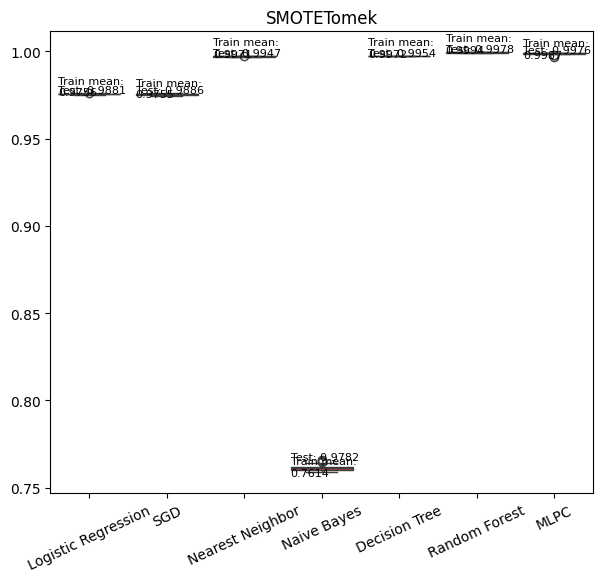

In [20]:
#SMOTETomek
X_train = X_train_bkp.copy()
y_train = y_train_bkp.copy()
from imblearn.combine import SMOTETomek
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
X_train, y_train = SMOTETomek(random_state=1).fit_resample(X_train, y_train)
print(X_train.shape, len(y_train[y_train == 0]), len(y_train[y_train == 1]))
evaluate('SMOTETomek')

In [ ]:
1/0

Logistic Regression 2024-11-10 13:39:17.793103
SGD 2024-11-10 13:40:01.189437
Nearest Neighbor 2024-11-10 13:40:55.930871
Naive Bayes 2024-11-10 14:10:28.679342
Decision Tree 2024-11-10 14:10:38.050016
Random Forest 2024-11-10 14:11:06.417616
MLPC 2024-11-10 14:18:22.361319


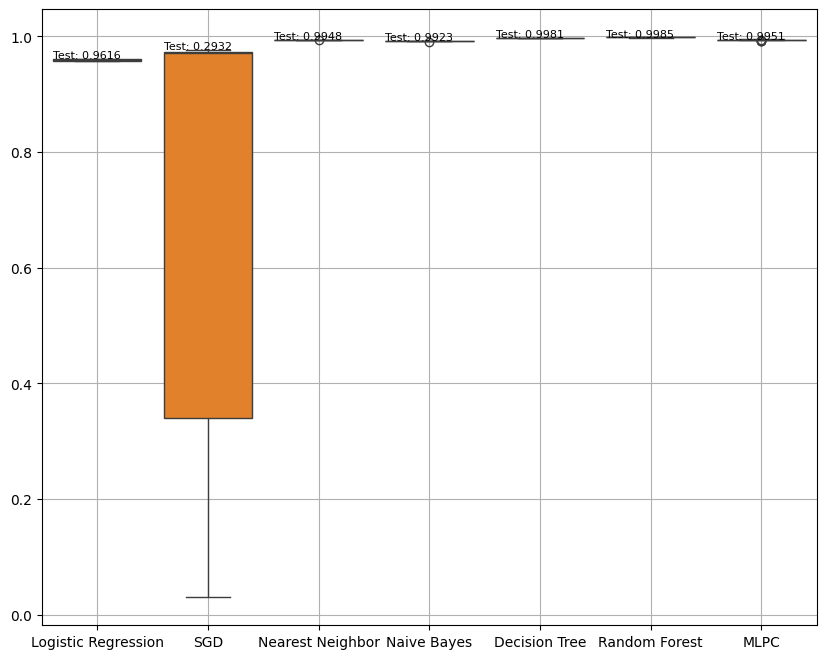

In [12]:
#one hot
#no Scaler, PF, PCA and SMOTE
evaluate()

Logistic Regression 2024-11-10 16:00:02.186298
SGD 2024-11-10 16:04:31.041622
Nearest Neighbor 2024-11-10 16:05:18.415136
Naive Bayes 2024-11-10 16:34:31.124479
Decision Tree 2024-11-10 16:34:41.407526
Random Forest 2024-11-10 16:35:09.341733
MLPC 2024-11-10 16:42:16.059323
2024-11-10 16:51:08.339100


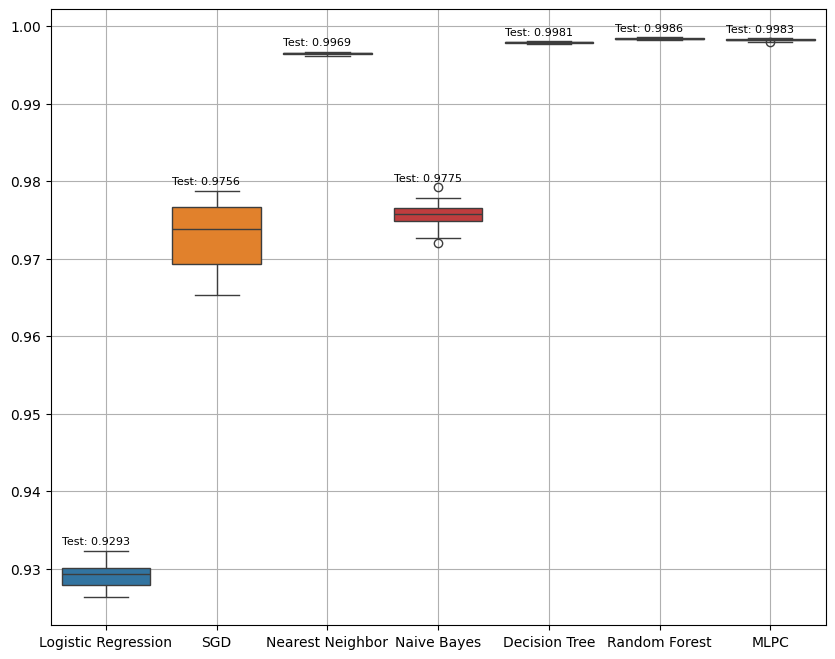

In [9]:
#one hot, Scaler
#no PF, PCA and SMOTE
evaluate()

Logistic Regression 2024-11-10 17:42:32.752014
SGD 2024-11-10 18:36:05.867762
Nearest Neighbor 2024-11-10 18:39:30.905697
Naive Bayes 2024-11-10 19:37:45.144277
Decision Tree 2024-11-10 19:39:55.308276
Random Forest 2024-11-10 19:45:00.133953
MLPC 2024-11-10 20:16:03.626139
2024-11-10 21:17:38.828184


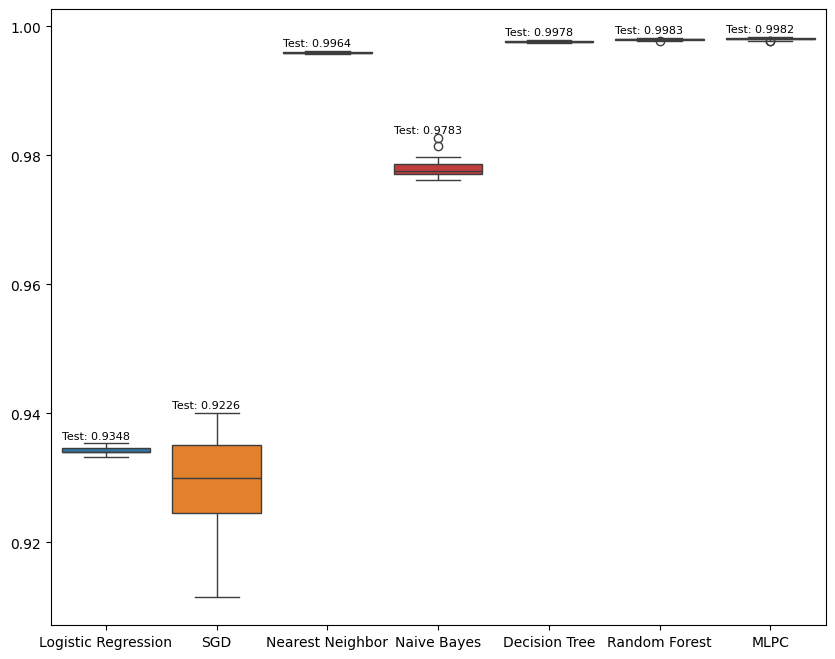

In [10]:
#one hot, Scaler, PF
#no PCA, SMOTE
evaluate()

Logistic Regression 2024-11-10 21:21:39.852466
SGD 2024-11-10 21:36:02.172542
Nearest Neighbor 2024-11-10 21:37:16.055818
Naive Bayes 2024-11-10 22:13:59.290497
Decision Tree 2024-11-10 22:14:13.387767
Random Forest 2024-11-10 22:21:02.289399
MLPC 2024-11-10 23:08:26.620795
2024-11-10 23:38:48.569257


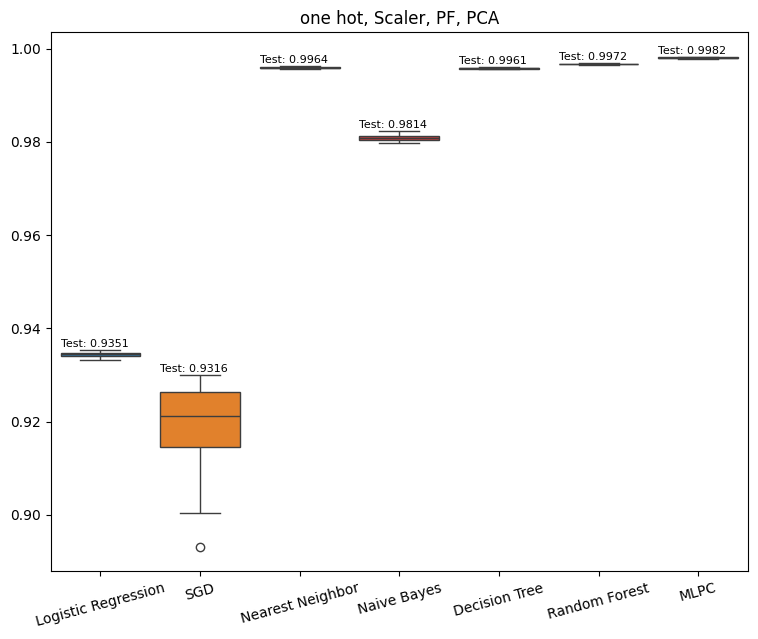

In [11]:
#one hot, Scaler, PF, PCA
#no SMOTE
evaluate('one hot, Scaler, PF, PCA')

Logistic Regression 2024-11-11 11:18:35.544698
SGD 2024-11-11 11:46:58.756241
Nearest Neighbor 2024-11-11 11:47:43.009213
Naive Bayes 2024-11-11 14:09:07.072472
Decision Tree 2024-11-11 14:10:18.044120
Random Forest 2024-11-11 14:32:46.839294
MLPC 2024-11-11 16:37:51.240239
2024-11-11 17:36:34.144749


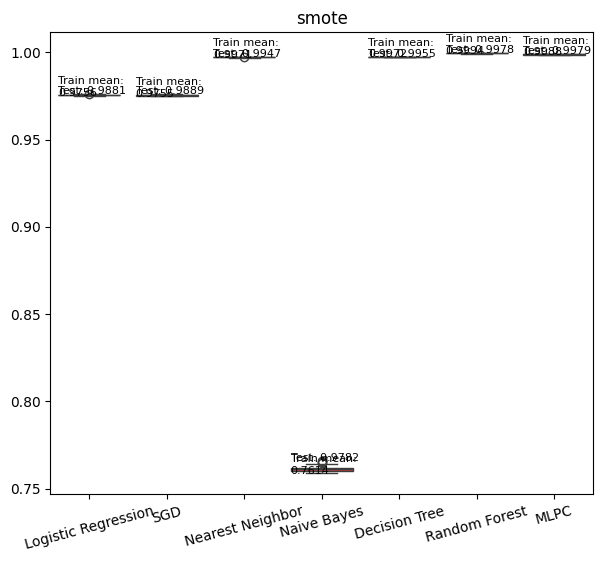

In [11]:
# one hot, Scaler,PF, PCA and SMOTE
evaluate('smote')

Logistic Regression 2024-11-11 17:46:00.013794
SGD 2024-11-11 17:46:03.622942
Nearest Neighbor 2024-11-11 17:46:04.458241
Naive Bayes 2024-11-11 17:46:12.518332
Decision Tree 2024-11-11 17:46:13.431851
Random Forest 2024-11-11 17:46:15.602058
MLPC 2024-11-11 17:46:30.398723


C:\Users\irama\.conda\envs\Python_10\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


2024-11-11 17:47:09.780607


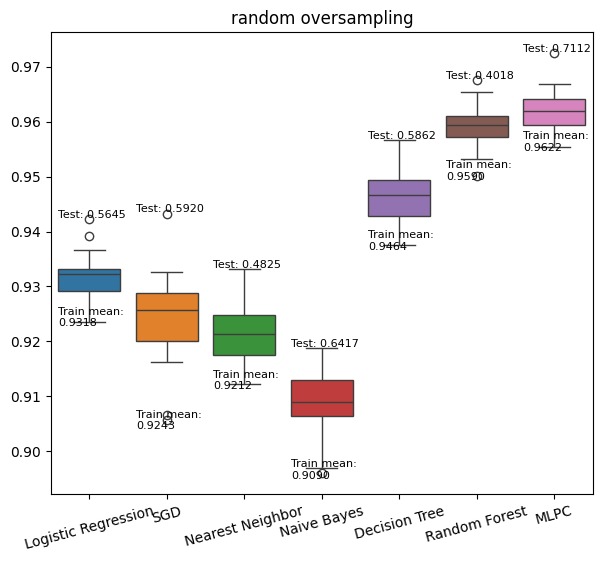

In [14]:
# one hot, Scaler,PF, PCA and NearMiss
evaluate('random oversampling')

In [ ]:
# one hot, Scaler,PF, PCA and TomekLinks-----------------
evaluate('TomekLinks')

Logistic Regression 2024-11-11 21:20:36.358016
SGD 2024-11-11 21:20:45.449114
Nearest Neighbor 2024-11-11 21:20:46.047316
Naive Bayes 2024-11-11 21:20:54.028122
Decision Tree 2024-11-11 21:20:54.918098
Random Forest 2024-11-11 21:20:56.575140
MLPC 2024-11-11 21:21:08.471931
2024-11-11 21:21:23.096280


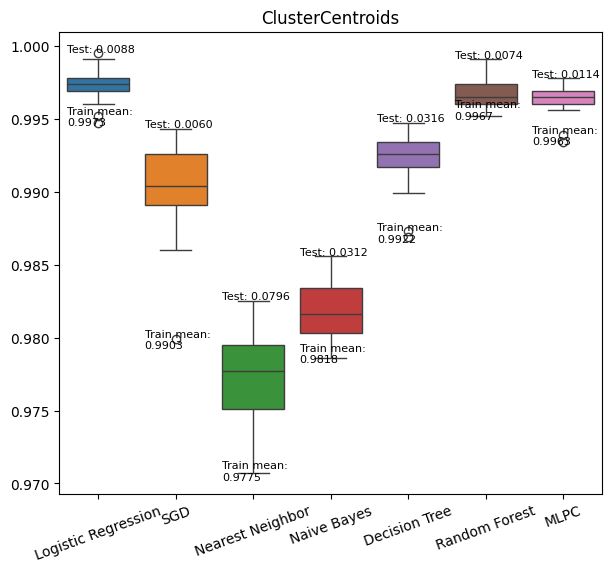

In [13]:
# one hot, Scaler,PF, PCA and ClusterCentroids
evaluate('ClusterCentroids')

Logistic Regression 2024-11-12 09:30:51.560729
SGD 2024-11-12 10:02:03.421177
Nearest Neighbor 2024-11-12 10:02:58.388735
Naive Bayes 2024-11-12 12:22:00.419848
Decision Tree 2024-11-12 12:23:26.727838
Random Forest 2024-11-12 12:34:30.002333
MLPC 2024-11-12 13:44:59.770093
2024-11-12 14:45:32.861035


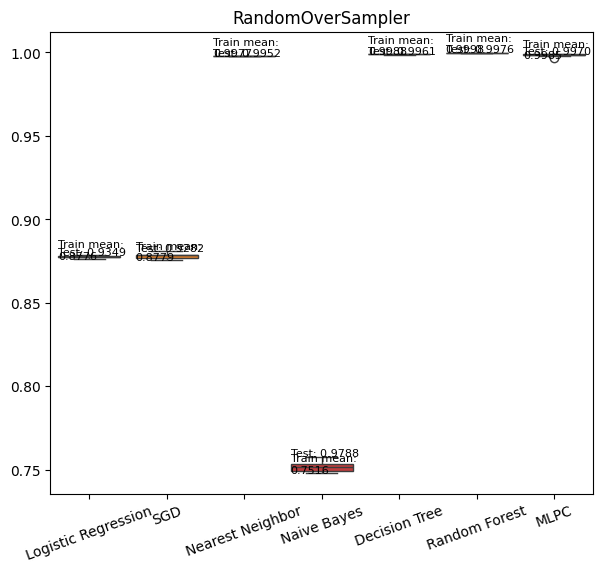

In [11]:
# one hot, Scaler,PF, PCA and RandomOverSampler
evaluate('RandomOverSampler')

Logistic Regression 2024-11-12 14:48:20.238163
SGD 2024-11-12 15:19:33.016749
Nearest Neighbor 2024-11-12 15:20:18.422120
Naive Bayes 2024-11-12 17:39:05.511514
Decision Tree 2024-11-12 17:40:39.915448
Random Forest 2024-11-12 18:05:11.468687
MLPC 2024-11-12 20:07:46.223547
2024-11-12 21:07:13.853181


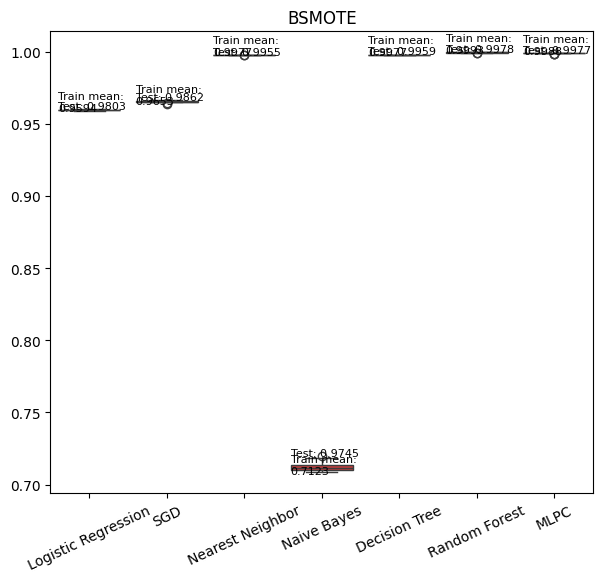

In [11]:
# one hot, Scaler,PF, PCA and BSMOTE
evaluate('BSMOTE')

Logistic Regression 2024-11-15 09:33:48.064060
SGD 2024-11-15 09:37:44.857014
Nearest Neighbor 2024-11-15 09:38:50.524702
Naive Bayes 2024-11-15 10:08:53.017449
Decision Tree 2024-11-15 10:09:02.892796
Random Forest 2024-11-15 10:20:44.889724
MLPC 2024-11-15 11:50:15.077196
2024-11-15 12:12:02.353300


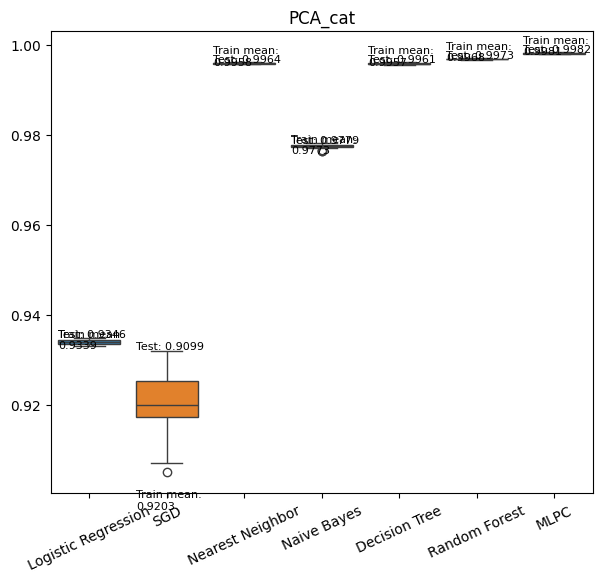

In [11]:
# PCA +cat
evaluate('PCA_cat')

Logistic Regression 2024-11-15 13:12:03.884012
SGD 2024-11-15 13:15:28.668854
Nearest Neighbor 2024-11-15 13:16:50.709217
Naive Bayes 2024-11-15 13:54:07.829780
Decision Tree 2024-11-15 13:54:22.029784
Random Forest 2024-11-15 14:15:17.388471
MLPC 2024-11-15 16:11:32.262451
2024-11-15 16:33:59.718257


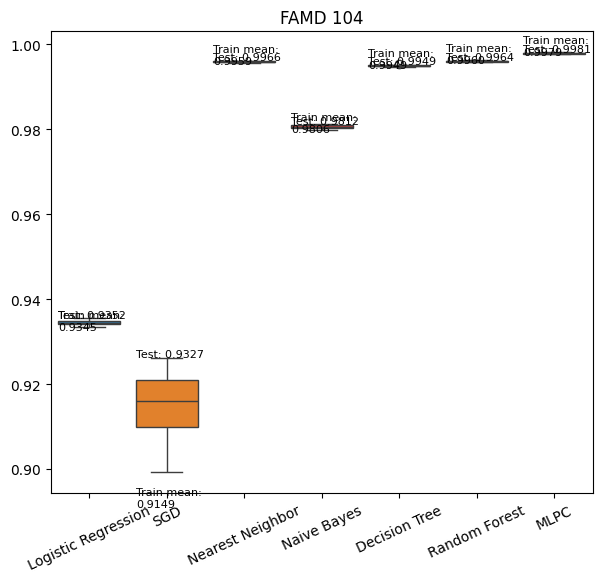

In [10]:
# FAMD 104 PF3
evaluate('FAMD 104')

Logistic Regression 2024-11-15 17:37:23.252746
SGD 2024-11-15 17:41:19.815681
Nearest Neighbor 2024-11-15 17:42:43.754345
Naive Bayes 2024-11-15 18:19:57.444910
Decision Tree 2024-11-15 18:20:11.522450
Random Forest 2024-11-15 18:40:51.917766
MLPC 2024-11-15 20:36:58.866634
2024-11-15 21:09:11.873454


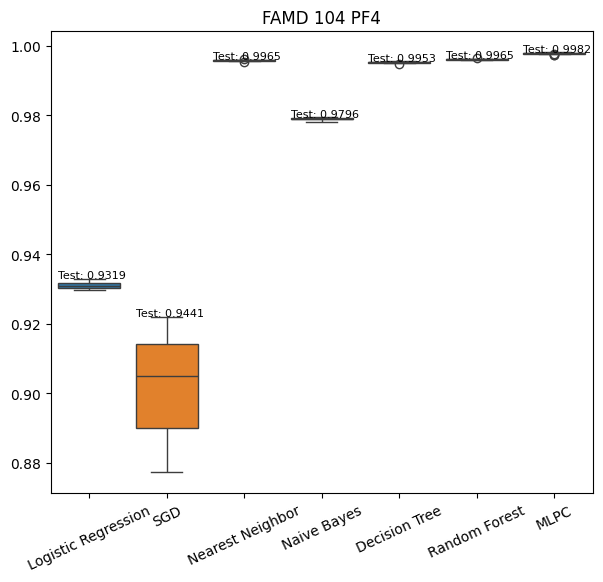

In [10]:
# FAMD 104 PF4
evaluate('FAMD 104 PF4')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
# one hot, Scaler,PF, PCA and 
evaluate('')

In [ ]:
pip install umap-learn